# RAGcore


## 1. .env settings 

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
load_dotenv(Path("../.env"))


http_proxy = os.getenv("http_proxy")
https_proxy = os.getenv("https_proxy")
HTTP_PROXY = os.getenv("HTTP_PROXY")
HTTPS_PROXY = os.getenv("HTTPS_PROXY")

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL", "openai/gpt-oss-120b")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "sentence-transformers/all-MiniLM-L6-v2")

assert GROQ_API_KEY, "GROQ_API_KEY not found — check that .env exists in the repo root and has a real key."
print("Setup OK")
print(f"  GROQ_MODEL = {GROQ_MODEL}")
print(f"  EMBEDDING_MODEL = {EMBEDDING_MODEL}")

Setup OK
  GROQ_MODEL = openai/gpt-oss-120b
  EMBEDDING_MODEL = sentence-transformers/all-MiniLM-L6-v2


## 2. Load a document

Extract text from a PDF, page by page

In [3]:
from pypdf import PdfReader

from pathlib import Path

SAMPLE_PDF_PATH = str(Path("../data/uploads/Deep Learning by Ian Goodfellow, Yoshua Bengio, Aaron Courville.pdf"))

reader = PdfReader(SAMPLE_PDF_PATH)
print(f"Loaded {len(reader.pages)} page(s) from {SAMPLE_PDF_PATH}")

pages_text = []
for page_num, page in enumerate(reader.pages, start=1):
    text = page.extract_text() or ""
    if text.strip():
        pages_text.append({"page": page_num, "text": text})

print(f"Extracted text from {len(pages_text)} non-empty page(s)")
print("\n--- Preview of page 1 ---")
print(pages_text[0]["text"][:500])

Loaded 801 page(s) from ../data/uploads/Deep Learning by Ian Goodfellow, Yoshua Bengio, Aaron Courville.pdf
Extracted text from 800 non-empty page(s)

--- Preview of page 1 ---
Deep Learning
Ian Goodfellow
Yoshua Bengio
Aaron Courville


## 3. Chunking

In [4]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE = int(os.getenv("CHUNK_SIZE", 1000))
CHUNK_OVERLAP = int(os.getenv("CHUNK_OVERLAP", 150))

page_documents = [
    Document(page_content=p["text"], metadata={"source": SAMPLE_PDF_PATH, "page": p["page"]})
    for p in pages_text
]

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = splitter.split_documents(page_documents)

for i, chunk in enumerate(chunks):
    chunk.metadata["chunk_index"] = i

print(f"Split {len(page_documents)} page(s) into {len(chunks)} chunk(s)\n")
print(f" No of chunks: {len(chunks)},\n chunk_size={CHUNK_SIZE},\n chunk_overlap={CHUNK_OVERLAP}")
print("\n--- Preview of chunk 0 ---")
print(chunks[0].page_content[:300])
print("\nMetadata:", chunks[0].metadata)

Split 800 page(s) into 2322 chunk(s)

 No of chunks: 2322,
 chunk_size=1000,
 chunk_overlap=150

--- Preview of chunk 0 ---
Deep Learning
Ian Goodfellow
Yoshua Bengio
Aaron Courville

Metadata: {'source': '../data/uploads/Deep Learning by Ian Goodfellow, Yoshua Bengio, Aaron Courville.pdf', 'page': 2, 'chunk_index': 0}


### Visualising chunks stats 


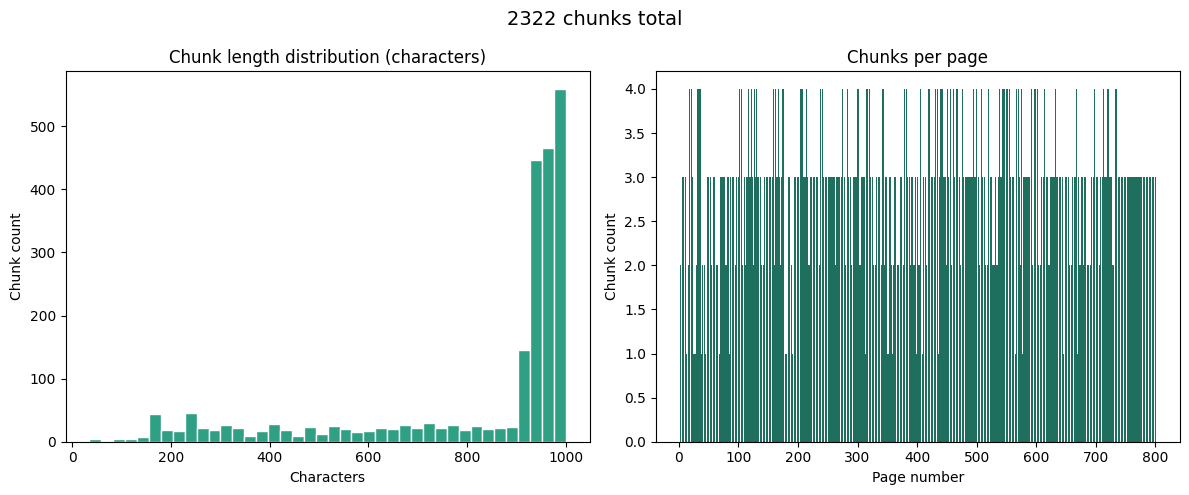

Chunk length — min: 35, max: 1000, avg: 823


In [5]:
import matplotlib.pyplot as plt
from collections import Counter

chunk_lengths = [len(c.page_content) for c in chunks]
chunk_pages = [c.metadata.get("page", 0) for c in chunks]

# Count chunks per page
page_counts = Counter(chunk_pages)
sorted_pages = sorted(page_counts.keys())
counts = [page_counts[p] for p in sorted_pages]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Chunk length histogram

axes[0].hist(
    chunk_lengths,
    bins=40,
    color="#2fa084",
    edgecolor="white"
)

axes[0].set_title("Chunk length distribution (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Chunk count")

#Chunks per page

axes[1].bar(
    sorted_pages,
    counts,
    color="#1f6f5f"
)

axes[1].set_title("Chunks per page")
axes[1].set_xlabel("Page number")
axes[1].set_ylabel("Chunk count")

fig.suptitle(f"{len(chunks)} chunks total", fontsize=14)
plt.tight_layout()
#plt.savefig('chunk_stat.png', dpi = 600)
plt.show()

# Statistics
print(
    f"Chunk length — min: {min(chunk_lengths)}, "
    f"max: {max(chunk_lengths)}, "
    f"avg: {sum(chunk_lengths) / len(chunk_lengths):.0f}"
)

## 4. Embedding

In [6]:
import os
from langchain_huggingface import HuggingFaceEmbeddings

# HF_HOME default — avoids downloading the model a second time if you've already used it through the running application.
HF_HOME = Path("../.hf_cache").resolve()
os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},  # keeps similarity scores well-behaved
)

sample_vector = embedding_model.embed_query(chunks[0].page_content)

print(f"Using HF_HOME")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Vector dimension: {len(sample_vector)}")
print(f"First 8 values: {sample_vector[:8]}")

Using HF_HOME
Embedding model: sentence-transformers/all-MiniLM-L6-v2
Vector dimension: 384
First 8 values: [-0.06303867697715759, -0.016751857474446297, 0.02572939544916153, -0.030512986704707146, -0.08692377060651779, 0.0557619072496891, 0.009984896518290043, -0.06722758710384369]


### what's actually happening under the hood

`HuggingFaceEmbeddings` (via `sentence-transformers`) is already running on PyTorch — it's a convenience wrapper around exactly these steps: tokenize → forward pass through the transformer → pool token vectors into one sentence vector → normalize. Let's do it manually, with raw `transformers` + `torch`, to see the mechanics directly and confirm we get the same result.

In [7]:
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F


raw_tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)
raw_model = AutoModel.from_pretrained(EMBEDDING_MODEL)
raw_model.eval()  


def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]  
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    summed = torch.sum(token_embeddings * mask, dim=1)
    counted = torch.clamp(mask.sum(dim=1), min=1e-9)  
    return summed / counted


def embed_raw_pytorch(text: str) -> torch.Tensor:
    tokens = raw_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad(): 
        output = raw_model(**tokens)
    embedding = mean_pooling(output, tokens["attention_mask"])
    embedding = F.normalize(embedding, p=2, dim=1)  
    return embedding.squeeze()


# Compare against the sentence-transformers wrapper's output for the same text
sample_text = chunks[100].page_content
raw_vector = embed_raw_pytorch(sample_text)
wrapped_vector = embedding_model.embed_query(sample_text)

print(f"Raw PyTorch vector shape: {tuple(raw_vector.shape)}")
print(f"Raw PyTorch first 8 values: {raw_vector[:8].tolist()}")
print(f"\nHuggingFaceEmbeddings first 8 values: {wrapped_vector[:8]}")

similarity = F.cosine_similarity(
    raw_vector.unsqueeze(0),
    torch.tensor(wrapped_vector).unsqueeze(0)
)
print(f"\nCosine similarity between raw-PyTorch and wrapped output: {similarity.item():.6f}")

Raw PyTorch vector shape: (384,)
Raw PyTorch first 8 values: [-0.08621171861886978, -0.0013607284054160118, 0.07335063070058823, -0.019600585103034973, 0.04947417601943016, 0.01534206047654152, 0.008418316021561623, -0.003463044064119458]

HuggingFaceEmbeddings first 8 values: [-0.08621171861886978, -0.0013607284054160118, 0.07335063070058823, -0.019600585103034973, 0.04947417601943016, 0.01534206047654152, 0.008418316021561623, -0.003463044064119458]

Cosine similarity between raw-PyTorch and wrapped output: 1.000000


### Embedding space visualization

Every chunk lives as a 384-dimensional vector — impossible to look at directly. PCA projects them down to 2D while preserving as much of the original variance as possible, so we can actually see how chunks cluster. Coloring by page number often reveals that nearby pages (same topic/chapter) cluster together spatially, even though PCA never saw page numbers — purely a byproduct of semantic similarity.

Embedding 2322 chunks for visualization......


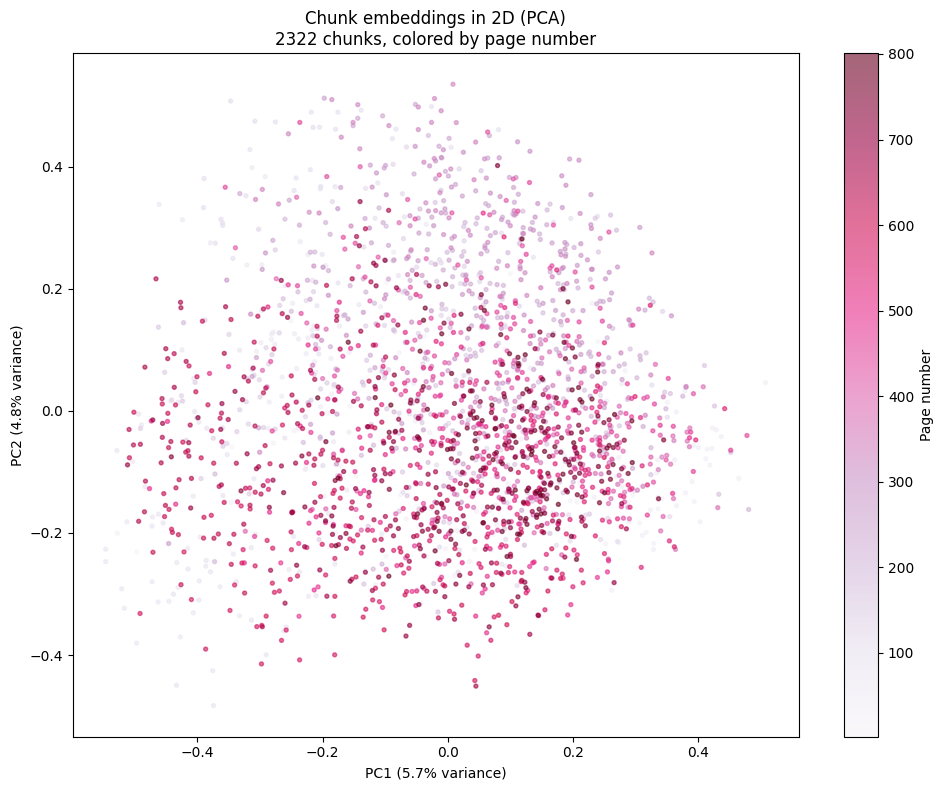

Total variance explained by 2 components: 10.5%


In [8]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print(f"Embedding {len(chunks)} chunks for visualization......")
all_vectors = embedding_model.embed_documents([c.page_content for c in chunks])
all_vectors = np.array(all_vectors)
pages = np.array([c.metadata.get("page", 0) for c in chunks])

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(all_vectors)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=pages, cmap="PuRd", s=8, alpha=0.6
)
plt.colorbar(scatter, label="Page number")
ax.set_title(f"Chunk embeddings in 2D (PCA)\n{len(chunks)} chunks, colored by page number")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
#plt.savefig('2d_PCA.png', dpi = 600)
plt.show()

print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.1%}")

### 3D - PCA

Embedding 2322 chunks for visualization......


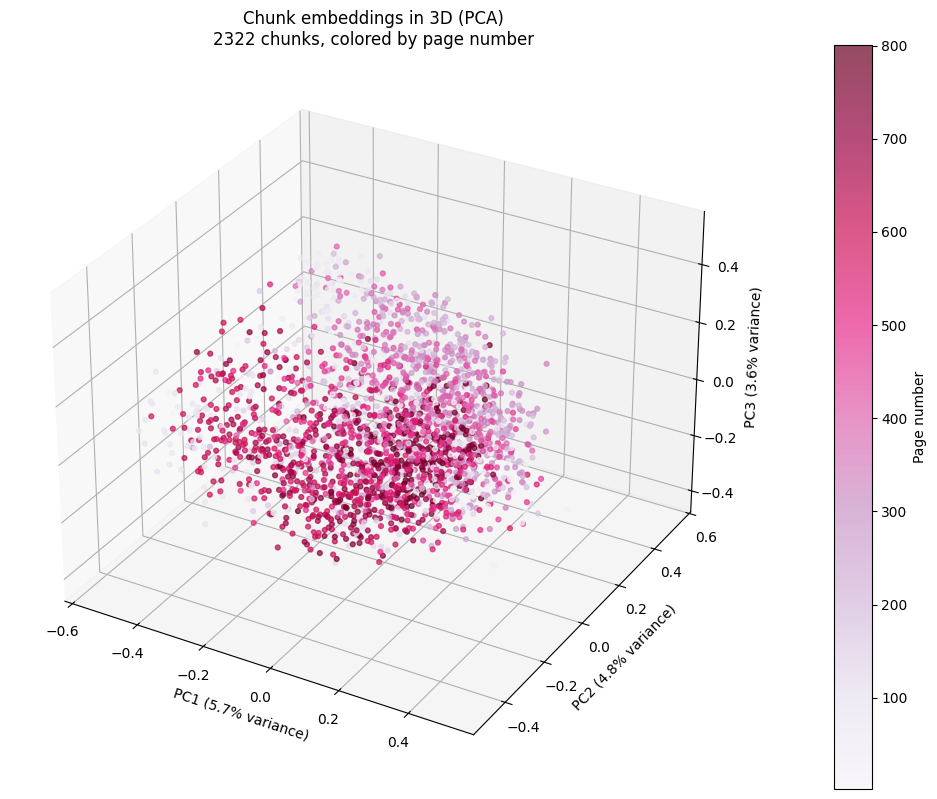

Total variance explained by 3 components: 14.1%


In [9]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print(f"Embedding {len(chunks)} chunks for visualization......")

all_vectors = embedding_model.embed_documents([c.page_content for c in chunks])
all_vectors = np.array(all_vectors)

pages = np.array([c.metadata.get("page", 0) for c in chunks])

# Reduce high-dimensional embeddings to 3 dimensions
pca = PCA(n_components=3)
coords_3d = pca.fit_transform(all_vectors)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    coords_3d[:, 0],   # PC1
    coords_3d[:, 1],   # PC2
    coords_3d[:, 2],   # PC3
    c=pages,
    cmap="PuRd",
    s=12,
    alpha=0.7
)

fig.colorbar(scatter, ax=ax, pad=0.1, label="Page number")

ax.set_title(
    f"Chunk embeddings in 3D (PCA)\n"
    f"{len(chunks)} chunks, colored by page number")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")

ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")

ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%} variance)")

plt.tight_layout()
#plt.savefig('3d_PCA.png', dpi = 600)
plt.show()

# Total variance explained
total_variance = sum(pca.explained_variance_ratio_)

print(
    f"Total variance explained by 3 components: "
    f"{total_variance:.1%}"
)

### 3D - UMAP

Reducing 2322 embeddings to 3D with UMAP...


/nmhs2/hari/work/UAV/Projects/RAGcore/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nmhs2/hari/work/UAV/Projects/RAGcore/venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


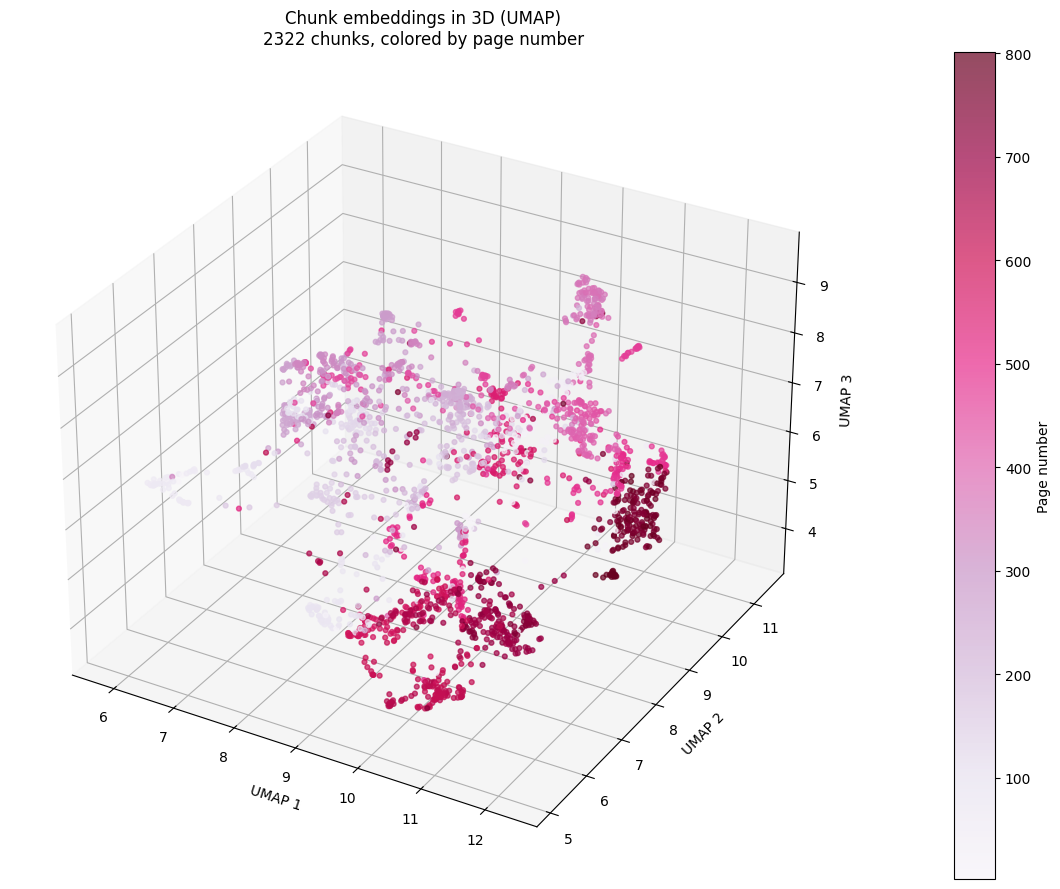

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import umap

print(f"Reducing {len(all_vectors)} embeddings to 3D with UMAP...")

# Reduce embeddings to 3 dimensions
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords_3d = reducer.fit_transform(all_vectors)

# Create 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    coords_3d[:, 0],
    coords_3d[:, 1],
    coords_3d[:, 2],
    c=pages,
    cmap="PuRd",
    s=12,
    alpha=0.7
)

# Colorbar
fig.colorbar(scatter,ax=ax,pad=0.1, label="Page number")

ax.set_title(
    f"Chunk embeddings in 3D (UMAP)\n"
    f"{len(chunks)} chunks, colored by page number")

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")

plt.tight_layout()
#plt.savefig('3d_UMAP.png', dpi = 600)
plt.show()

## 5. Vector store (Chroma)

Embed all the chunks and store them in a persistent Chroma collection — this is what makes similarity search possible: instead of comparing text directly, we compare the embedding vectors. Uses a separate collection (`notebook_demo`) so this doesn't touch the web app's actual data.

In [11]:
from langchain_chroma import Chroma

NOTEBOOK_CHROMA_DIR = str(Path("./chroma_demo").resolve())

vectorstore = Chroma(
    collection_name="notebook_demo",
    embedding_function=embedding_model,
    persist_directory=NOTEBOOK_CHROMA_DIR,
)

# Deterministic IDs (chunk_index-based) mean re-running this cell overwrites the same vectors instead of duplicating them.
ids = [f"chunk_{c.metadata['chunk_index']}" for c in chunks]

vectorstore.add_documents(documents=chunks, ids=ids)

print(f"Stored {len(chunks)} chunk(s) in Chroma collection 'notebook_demo'")
print(f"Persisted to Directory")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Stored 2322 chunk(s) in Chroma collection 'notebook_demo'
Persisted to Directory


In [12]:
chroma_data = vectorstore.get(
    include=["embeddings", "metadatas"]
)

print(f"Loaded {len(chroma_data['embeddings'])} embeddings")

Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Loaded 2322 embeddings


### Pairwise similarity heatmap

How similar are chunks to each other? A full 2,322×2,322 matrix would be unreadable, so we sample a subset — this reveals blocks of high similarity (likely nearby/related content) versus mostly-dissimilar chunks (unrelated topics).

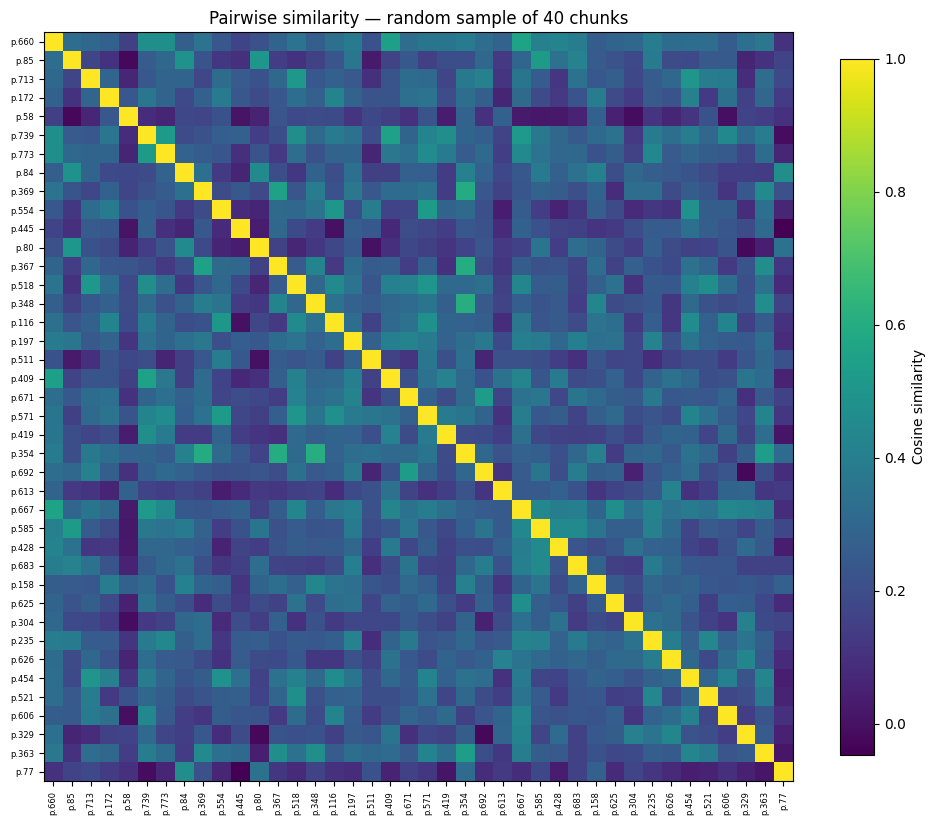

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

SAMPLE_SIZE = 40

rng = np.random.default_rng(seed=42)
sample_idx = rng.choice(len(chroma_data["embeddings"]), size=SAMPLE_SIZE, replace=False)

sample_vectors = np.array(chroma_data["embeddings"])[sample_idx]
sample_pages = [chroma_data["metadatas"][i].get("page", "?") for i in sample_idx]
labels = [f"p.{p}" for p in sample_pages]

sim_matrix = cosine_similarity(sample_vectors)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(sim_matrix, cmap="viridis")

ax.set_xticks(range(SAMPLE_SIZE))
ax.set_yticks(range(SAMPLE_SIZE))
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_yticklabels(labels, fontsize=6)

fig.colorbar(im, ax=ax, label="Cosine similarity", shrink=0.8)
ax.set_title(f"Pairwise similarity — random sample of {SAMPLE_SIZE} chunks")
plt.tight_layout()
plt.show()



### Embedding_space (page) and Embedding_space (cluster)

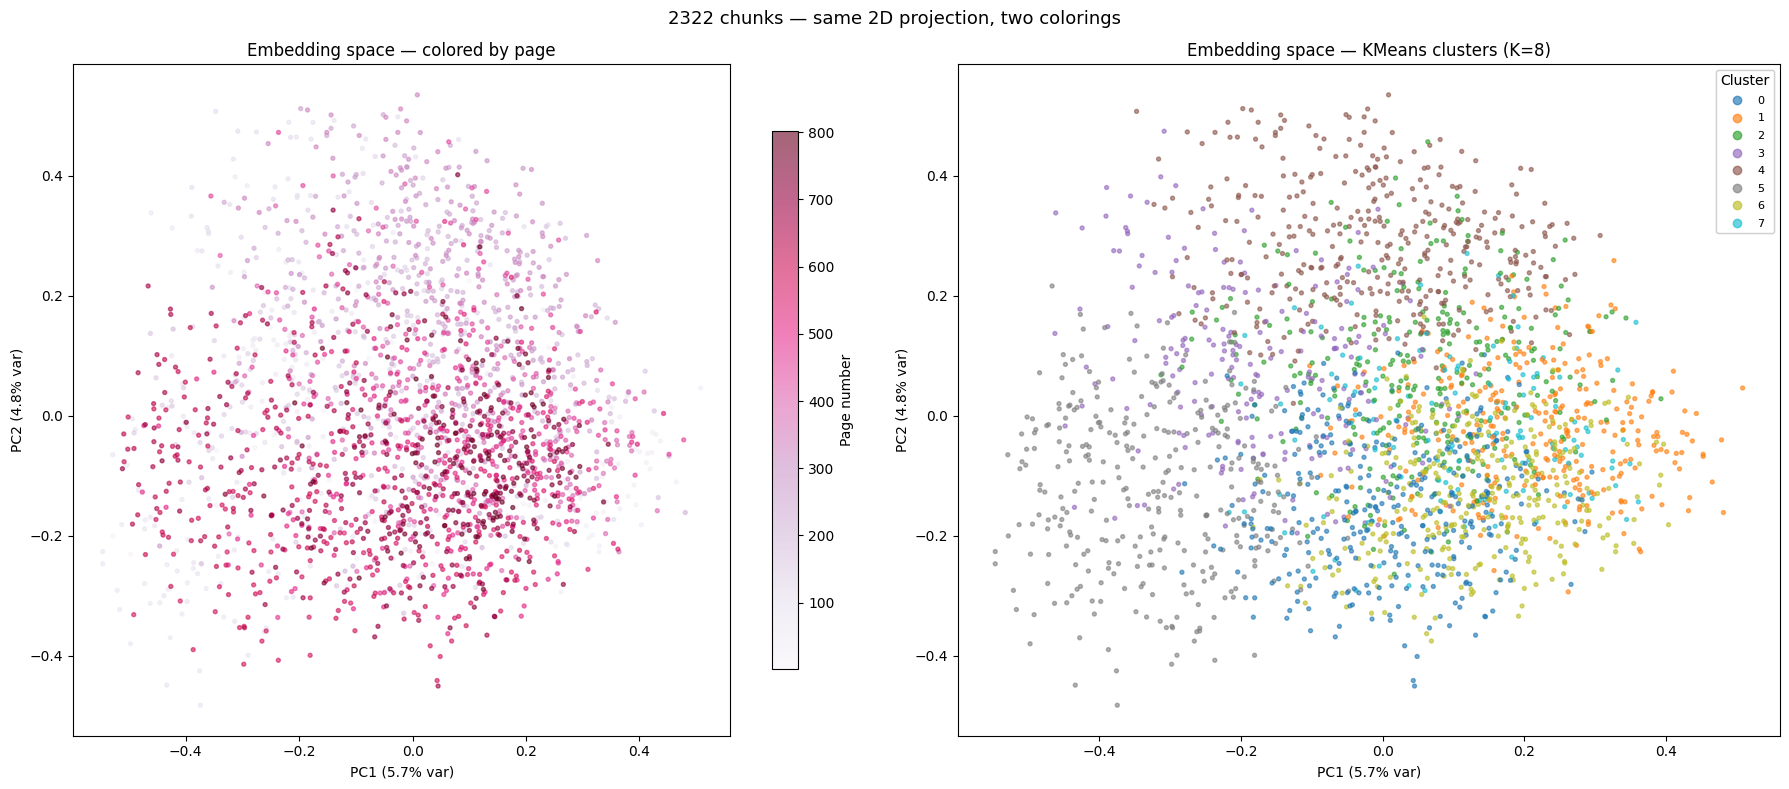

In [14]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

N_CLUSTERS = 8

all_vectors = np.array(chroma_data["embeddings"])
all_pages = [m.get("page", 0) for m in chroma_data["metadatas"]]

# Same 2D projection used for both plots, so they're directly comparable
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(all_vectors)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(all_vectors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: colored by page number ---
sc1 = ax1.scatter(coords_2d[:, 0], coords_2d[:, 1], c=all_pages, cmap="PuRd", s=8, alpha=0.6)
fig.colorbar(sc1, ax=ax1, label="Page number", shrink=0.8)
ax1.set_title("Embedding space — colored by page")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")

# --- Right: colored by KMeans cluster ---
sc2 = ax2.scatter(coords_2d[:, 0], coords_2d[:, 1], c=cluster_labels, cmap="tab10", s=8, alpha=0.6)
legend = ax2.legend(*sc2.legend_elements(), title="Cluster", loc="best", fontsize=8)
ax2.add_artist(legend)
ax2.set_title(f"Embedding space — KMeans clusters (K={N_CLUSTERS})")
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")

fig.suptitle(f"{len(all_vectors)} chunks — same 2D projection, two colorings", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Vector similarity search

Ask a question, embed it the same way we embedded the chunks, and find the most similar chunks by vector distance. This is the simplest form of retrieval — no keyword matching, no reranking yet, just "what's semantically closest."

In [22]:
sample_question = "Precision is the fraction of what?"  # change this to something your document actually covers

results = vectorstore.similarity_search_with_relevance_scores(sample_question, k=5)

print(f"Question: {sample_question}\n")
for i, (doc, score) in enumerate(results, start=1):
    page = doc.metadata.get("page", "?")
    print(f"[{i}] score={score:.3f}  page={page}")
    print(f"    {doc.page_content[:150]}...")
    print()

Question: Precision is the fraction of what?

[1] score=0.352  page=96
    of bit patterns. This means that for almost all real numbers, we incur some
approximation error when we represent the number in the computer. In many
...

[2] score=0.284  page=467
    analog (Graf and Jackel 1989 Mead and Ismail 2012, ; , ) (based on physical imple-
mentations of continuous values as voltages or currents) or hybrid ...

[3] score=0.191  page=439
    of allowing spam messages.
Sometimes we wish to train a binary classiﬁer that is intended to detect some
rare event. For example, we might design a me...

[4] score=0.185  page=500
    that are probably negative (facts that are probably false) is to begin with a true
fact and create corrupted versions of that fact, for example by rep...

[5] score=0.126  page=542
    Many information processing tasks can be very easy or very diﬃcult depending
on how the information is represented. This is a general principle applic...



## 7. Hybrid retrieval — adding BM25 keyword search

Vector search is great at semantic similarity but can miss exact keyword/term matches. BM25 is a classic keyword-ranking algorithm that catches those. We run both and merge the results into one deduplicated candidate pool

In [23]:
from langchain_community.retrievers import BM25Retriever

CANDIDATE_K = 10

vector_results = vectorstore.similarity_search(sample_question, k=CANDIDATE_K)

# --- BM25 candidates ---
# BM25Retriever builds its index from an in-memory document list — here
# we just reuse the `chunks` list we already built, no separate storage
bm25_retriever = BM25Retriever.from_documents(chunks)
bm25_retriever.k = CANDIDATE_K
bm25_results = bm25_retriever.invoke(sample_question)

# --- Merge + dedupe by chunk_index ---
merged = {}
for doc in vector_results + bm25_results:
    key = doc.metadata.get("chunk_index")
    merged[key] = doc

candidates = list(merged.values())

print(f"Vector search: {len(vector_results)} result(s)")
print(f"BM25 search:   {len(bm25_results)} result(s)")
print(f"Merged unique candidates: {len(candidates)}")
print("\n--- Sample candidate ---")
print(candidates[0].page_content[:200])

Vector search: 10 result(s)
BM25 search:   10 result(s)
Merged unique candidates: 19

--- Sample candidate ---
of bit patterns. This means that for almost all real numbers, we incur some
approximation error when we represent the number in the computer. In many
cases, this is just rounding error. Rounding error


## 8. Reranking

Vector and BM25 retrieval are both fast but approximate. A cross-encoder reranker scores each candidate against the query directly (rather than comparing precomputed embeddings), which is slower but far more precise — it's what actually decides which chunks are good enough to reach the LLM.

In [25]:
from sentence_transformers import CrossEncoder

RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
RERANK_TOP_N = 4

reranker = CrossEncoder(RERANKER_MODEL)

pairs = [(sample_question, doc.page_content) for doc in candidates]
scores = reranker.predict(pairs)

scored_candidates = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)

print(f"question: {sample_question}")
print(f"Top {RERANK_TOP_N} after reranking:\n")
for doc, score in scored_candidates[:RERANK_TOP_N]:
    page = doc.metadata.get("page", "?")
    print(f"score={score:.3f}  page={page}")
    print(f"  {doc.page_content[:150]}...")

top_chunks = [doc for doc, score in scored_candidates[:RERANK_TOP_N]]

question: Precision is the fraction of what?
Top 4 after reranking:

score=2.162  page=439
  of allowing spam messages.
Sometimes we wish to train a binary classiﬁer that is intended to detect some
rare event. For example, we might design a me...
score=-3.343  page=500
  that are probably negative (facts that are probably false) is to begin with a true
fact and create corrupted versions of that fact, for example by rep...
score=-5.961  page=440
  CHAPTER 11. PRACTICAL METHODOLOGY
network designed to detect a disease outputs ˆy = P (y = 1 | x), estimating the
probability that a person whose medi...
score=-6.209  page=467
  analog (Graf and Jackel 1989 Mead and Ismail 2012, ; , ) (based on physical imple-
mentations of continuous values as voltages or currents) or hybrid ...


## 9. Generate answer

Explicit "don't use outside knowledge" instructions, and a rule to say so honestly when the context doesn't have enough information.

In [18]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

SYSTEM_PROMPT = """You are a helpful assistant that answers questions using ONLY the \
provided context from the user's uploaded documents.

Rules:
- Base your answer strictly on the context below. Do not use outside knowledge.
- If the context doesn't contain enough information to answer, say so clearly \
instead of guessing.
- Be concise and direct.
- Do not fabricate document names, page numbers, or facts not present in the context.

Context:
{context}
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human", "{question}"),
])

llm = ChatGroq(api_key=GROQ_API_KEY, model=GROQ_MODEL, temperature=0.1)

# Build the numbered context block from whichever chunks survived
# reranking (+ filtering, if you ran the optional threshold cell).
context_parts = []
for i, doc in enumerate(top_chunks, start=1):
    page = doc.metadata.get("page", "?")
    context_parts.append(f"[{i}] (Source: page {page})\n{doc.page_content}")
context = "\n\n".join(context_parts)

chain = prompt | llm
response = chain.invoke({"context": context, "question": sample_question})

print(f"Question: {sample_question}\n")
print(f"Answer:\n{response.content}")
print(f"\n--- Grounded in {len(top_chunks)} chunk(s) ---")
for doc in top_chunks:
    print(f"  page {doc.metadata.get('page', '?')}")

Question: Precision is the fraction of what? ?

Answer:
Precision is the fraction of detections reported by the model that were correct.

--- Grounded in 4 chunk(s) ---
  page 439
  page 500
  page 202
  page 467


In [ ]:
from pydantic import BaseModel, Field


class AnswerWithGrounding(BaseModel):
    answer: str = Field(description="The answer to the user's question, written naturally.")
    found_in_context: bool = Field(
        description=(
            "True if the provided context actually contained enough information "
            "to answer the question. False if the context was irrelevant or "
            "insufficient, and the answer is essentially 'I don't know'."
        )
    )


structured_llm = llm.with_structured_output(AnswerWithGrounding)


def ask(question: str, candidate_k: int = 10, top_n: int = 4) -> dict:

    # Hybrid retrieval
    vector_results = vectorstore.similarity_search(question, k=candidate_k)
    bm25_retriever.k = candidate_k
    bm25_results = bm25_retriever.invoke(question)

    merged = {}
    for doc in vector_results + bm25_results:
        merged[doc.metadata.get("chunk_index")] = doc
    candidates = list(merged.values())

    if not candidates:
        return {"answer": "No candidates found.", "sources": [], "chunks": []}

    # Rerank — always take top_n, no score filtering (see earlier discussion)
    pairs = [(question, doc.page_content) for doc in candidates]
    scores = reranker.predict(pairs)
    top_results = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)[:top_n]

    # Generate — structured output gives us found_in_context directly
    context = "\n\n".join(
        f"[{i}] (Source: page {doc.metadata.get('page', '?')})\n{doc.page_content}"
        for i, (doc, _) in enumerate(top_results, start=1)
    )
    response: AnswerWithGrounding = (prompt | structured_llm).invoke(
        {"context": context, "question": question}
    )

    sources = []
    top_chunks = []
    if response.found_in_context:
        sources = [
            {"page": doc.metadata.get("page", "?"), "score": round(float(score), 3)}
            for doc, score in top_results
        ]
        top_chunks = [doc for doc, _ in top_results]
    else:
        print("(LLM indicated the context didn't support an answer — sources omitted)")

    return {"answer": response.answer, "sources": sources, "chunks": top_chunks}

In [33]:
user_question = input("Ask a question about the document: ")

result = ask(user_question)

print(f"\nQuestion: {user_question}")
print(f"\nAnswer:\n{result['answer']}")

if result["sources"]:
    print("\nSources:")
    for s in result["sources"]:
        print(f"  page {s['page']}  (score={s['score']})")
else:
    print("\n(No sources — context didn't support this answer)")


Question: dropout trains the ensemble consisting of?

Answer:
Dropout trains an ensemble of all possible sub‑networks that can be formed by removing any non‑output units from the underlying base network.

Sources:
  page 274  (score=7.075)
  page 283  (score=5.323)
  page 282  (score=3.846)
  page 282  (score=3.777)


### Answer evaluation (Faithfulness & Answer Relevancy)

Same on-demand scoring as the "Check this answer" feature in the web app — RAGAS judges whether the answer is grounded in the retrieved context (Faithfulness) and whether it addresses the question asked (Answer Relevancy). Reuses the same Groq LLM and HuggingFace embeddings already set up above.

Note: if the last `ask()` call had `found_in_context=False` (empty sources), there's nothing meaningful to evaluate — Faithfulness needs actual context to check the answer against.

In [34]:
from ragas import SingleTurnSample
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.llms import LangchainLLMWrapper
from ragas.metrics import AnswerRelevancy, Faithfulness

evaluator_llm = LangchainLLMWrapper(llm)                            # reusing the ChatGroq instance from earlier
evaluator_embeddings = LangchainEmbeddingsWrapper(embedding_model)   # reusing the embedding model from earlier

faithfulness_metric = Faithfulness(llm=evaluator_llm)
relevancy_metric = AnswerRelevancy(llm=evaluator_llm, embeddings=evaluator_embeddings)


async def evaluate_answer(question: str, result: dict) -> dict | None:
    """Scores a result from ask(). Returns None if there were no source
    chunks to evaluate against (i.e. the LLM said it didn't find an
    answer in the context)."""
    if not result["chunks"]:
        print("No source chunks to evaluate — this answer wasn't grounded in any context.")
        return None

    sample = SingleTurnSample(
        user_input=question,
        response=result["answer"],
        retrieved_contexts=[doc.page_content for doc in result["chunks"]],
    )
    faithfulness_score = await faithfulness_metric.single_turn_ascore(sample)
    relevancy_score = await relevancy_metric.single_turn_ascore(sample)
    return {
        "faithfulness": round(float(faithfulness_score), 3),
        "answer_relevancy": round(float(relevancy_score), 3),
    }


# Evaluate the most recent ask() result
scores = await evaluate_answer(user_question, result)
if scores:
    print(f"Faithfulness:     {scores['faithfulness'] * 100:.0f}%")
    print(f"Answer Relevancy: {scores['answer_relevancy'] * 100:.0f}%")

Faithfulness:     100%
Answer Relevancy: 55%
